# FBK Comparison Plots
Genera i plot di confronto **timing resolution** e **collected charge** vs bias voltage.

- **Sezione 1**: inserisci i dati
- **Sezione 2**: genera plot con 4 sensori
- **Sezione 3**: genera plot con singolo sensore

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

%matplotlib widget

plt.style.use(hep.style.CMS)


In [ ]:

# Titolo e sottotitolo di default
PLOT_TITLE    = "FBK Comparison (June 2026)"
PLOT_SUBTITLE = "Test Beam"
# ── Palette colori — scegli da qui per i nuovi sensori ──────
PALETTE = {
    # reds
    'red':              '#bd1f01',
    'red_light':        '#e05040',
    'red_dark':         '#7a1200',
    'crimson':          '#dc143c',
    'rose':             '#e8627a',

    # oranges
    'orange':           '#e07b00',
    'orange_light':     '#f5a233',
    'orange_dark':      '#a05500',
    'dark_orange':      '#e76300',
    'amber':            '#ffb300',

    # yellows
    'yellow':           '#ffa90e',
    'yellow_light':     '#ffd54f',
    'yellow_dark':      '#c77800',
    'gold':             '#d4a017',
    'lime_yellow':      '#d4e157',

    # greens
    'green':            '#417328',
    'green_light':      '#66a63e',
    'green_dark':       '#264d14',
    'lime':             '#8bc34a',
    'mint':             '#4caf7d',
    'forest':           '#2e7d32',

    # teals / cyans
    'teal':             '#00897b',
    'teal_light':       '#4db6ac',
    'teal_dark':        '#00574b',
    'cyan':             '#92dadd',
    'cyan_dark':        '#0097a7',
    'aqua':             '#00bcd4',

    # blues
    'blue':             '#3f90da',
    'blue_light':       '#7ec8f0',
    'blue_dark':        '#1565c0',
    'dark_blue':        '#1a3f5c',
    'navy':             '#0d2340',
    'sky':              '#64b5f6',
    'cobalt':           '#1e4d8c',
    'indigo':           '#3949ab',

    # purples
    'purple':           '#832db6',
    'purple_light':     '#b36fd4',
    'purple_dark':      '#560a85',
    'violet':           '#6a1b9a',
    'lavender':         '#ce93d8',
    'mauve':            '#c77dff',

    # pinks
    'pink':             '#e35be5',
    'pink_light':       '#f48fb1',
    'pink_dark':        '#ad1457',
    'hot_pink':         '#f06292',
    'fuchsia':          '#e91e8c',

    # browns
    'brown':            '#a96b59',
    'brown_light':      '#c8957c',
    'brown_dark':       '#6d3b2b',
    'tan':              '#c4a882',
    'sienna':           '#a0522d',

    # olives / neutrals
    'olive':            '#b9ac70',
    'olive_dark':       '#827717',
    'khaki':            '#d4c97a',
    'sand':             '#c2b280',

    # greys
    'grey':             '#717581',
    'grey_light':       '#aab0ba',
    'grey_dark':        '#424651',
    'charcoal':         '#2e3035',
    'silver':           '#c0c4cc',
}

RED          = PALETTE['red']
RED_LIGHT    = PALETTE['red_light']
RED_DARK     = PALETTE['red_dark']
CRIMSON      = PALETTE['crimson']
ROSE         = PALETTE['rose']

ORANGE       = PALETTE['orange']
ORANGE_LIGHT = PALETTE['orange_light']
ORANGE_DARK  = PALETTE['orange_dark']
DARK_ORANGE  = PALETTE['dark_orange']
AMBER        = PALETTE['amber']

YELLOW       = PALETTE['yellow']
YELLOW_LIGHT = PALETTE['yellow_light']
YELLOW_DARK  = PALETTE['yellow_dark']
GOLD         = PALETTE['gold']
LIME_YELLOW  = PALETTE['lime_yellow']

GREEN        = PALETTE['green']
GREEN_LIGHT  = PALETTE['green_light']
GREEN_DARK   = PALETTE['green_dark']
LIME         = PALETTE['lime']
MINT         = PALETTE['mint']
FOREST       = PALETTE['forest']

TEAL         = PALETTE['teal']
TEAL_LIGHT   = PALETTE['teal_light']
TEAL_DARK    = PALETTE['teal_dark']
CYAN         = PALETTE['cyan']
CYAN_DARK    = PALETTE['cyan_dark']
AQUA         = PALETTE['aqua']

BLUE         = PALETTE['blue']
BLUE_LIGHT   = PALETTE['blue_light']
BLUE_DARK    = PALETTE['blue_dark']
DARK_BLUE    = PALETTE['dark_blue']
NAVY         = PALETTE['navy']
SKY          = PALETTE['sky']
COBALT       = PALETTE['cobalt']
INDIGO       = PALETTE['indigo']

PURPLE       = PALETTE['purple']
PURPLE_LIGHT = PALETTE['purple_light']
PURPLE_DARK  = PALETTE['purple_dark']
VIOLET       = PALETTE['violet']
LAVENDER     = PALETTE['lavender']
MAUVE        = PALETTE['mauve']

PINK         = PALETTE['pink']
PINK_LIGHT   = PALETTE['pink_light']
PINK_DARK    = PALETTE['pink_dark']
HOT_PINK     = PALETTE['hot_pink']
FUCHSIA      = PALETTE['fuchsia']

BROWN        = PALETTE['brown']
BROWN_LIGHT  = PALETTE['brown_light']
BROWN_DARK   = PALETTE['brown_dark']
TAN          = PALETTE['tan']
SIENNA       = PALETTE['sienna']

OLIVE        = PALETTE['olive']
OLIVE_DARK   = PALETTE['olive_dark']
KHAKI        = PALETTE['khaki']
SAND         = PALETTE['sand']

GREY         = PALETTE['grey']
GREY_LIGHT   = PALETTE['grey_light']
GREY_DARK    = PALETTE['grey_dark']
CHARCOAL     = PALETTE['charcoal']
SILVER       = PALETTE['silver']

## 1. Inserisci i dati
Ogni sensore è un dizionario con:
- `label`: stringa per la legenda
- `color`: colore della linea
- `linestyle`: `'-'` per solid (TB), `'--'` per dashed (Beta setup)
- `voltage`: lista dei bias voltage [V]
- `resolution` / `resolution_err`: timing resolution [ps] e incertezze
- `charge` / `charge_err`: collected charge [fC] e incertezze

## 2. Funzioni di plotting

In [135]:

def _prepare_series(sensor, quantity):
    voltages = sensor['voltage']
    values   = sensor[quantity]
    errors   = sensor.get(f'{quantity}_err')

    v_out, y_out, e_out = [], [], []
    for i, (vv, yy) in enumerate(zip(voltages, values)):
        if yy is None:
            continue
        ee = errors[i] if errors is not None else None
        v_out.append(vv); y_out.append(yy); e_out.append(ee)

    if all(e is None for e in e_out):
        e_out = None
    else:
        e_out = np.array(e_out, dtype=float)

    return np.array(v_out), np.array(y_out), e_out


def _prepare_res_vs_charge(sensor):
    chg_out, res_out = [], []
    for v, r, c in zip(sensor['voltage'], sensor['resolution'], sensor['charge']):
        if r is not None and c is not None:
            chg_out.append(c)
            res_out.append(r)
    return np.array(chg_out), np.array(res_out)


def _resolve(selection):
    if selection == 'all':
        return sensors
    if isinstance(selection, int):
        return [sensors[selection]]
    return [sensors[i] for i in selection]


def _errorbar_kwargs(sensor, e):
    mfc = 'none' if sensor.get('hollow', False) else sensor['color']
    return dict(
        label           = sensor['label'],
        color           = sensor['color'],
        linestyle       = sensor['linestyle'],
        marker          = sensor.get('marker', 'o'),
        markersize      = sensor.get('markersize', 5),
        linewidth       = 1.6,
        capsize         = 3 if e is not None else 0,
        markerfacecolor = mfc,
        markeredgewidth = 1.5,
    )


def plot_comparison(sensor_list, quantity, ylabel, ylim,
                    title=PLOT_TITLE, subtitle=PLOT_SUBTITLE,
                    save_path=None, figsize=(9, 7)):
    fig, ax = plt.subplots(figsize=figsize)
    for s in sensor_list:
        v, y, e = _prepare_series(s, quantity)
        ax.errorbar(v, y, yerr=e, **_errorbar_kwargs(s, e))

    ax.set_xlabel('Bias voltage [V]')
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    leg = ax.legend(loc='upper right' if quantity == 'charge' else 'lower left',
                    frameon=True, fontsize=11)
    leg.set_draggable(True)
    ax.text(0.03, 0.97, subtitle, transform=ax.transAxes,
            va='top', ha='left', fontsize=12)
    hep.cms.label(label='ETL Preliminary', data=True, rlabel=title, ax=ax, fontsize=15)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Salvato: {save_path}')
    plt.show()
    return fig


def plot_res_vs_charge(sensor_list, title=PLOT_TITLE, subtitle=PLOT_SUBTITLE,
                       save_path=None, figsize=(9, 7)):
    fig, ax = plt.subplots(figsize=figsize)
    for s in sensor_list:
        chg, res = _prepare_res_vs_charge(s)
        if len(chg) == 0:
            continue
        mfc = 'none' if s.get('hollow', False) else s['color']
        ax.plot(chg, res,
                label           = s['label'],
                color           = s['color'],
                linestyle       = s['linestyle'],
                marker          = s.get('marker', 'o'),
                markersize      = s.get('markersize', 5),
                linewidth       = 1.6,
                markerfacecolor = mfc,
                markeredgewidth = 1.5)

    ax.set_xlabel('Collected charge [fC]')
    ax.set_ylabel('Time resolution [ps]')
    leg = ax.legend(loc='upper right', frameon=True, fontsize=11)
    leg.set_draggable(True)
    ax.text(0.03, 0.97, subtitle, transform=ax.transAxes,
            va='top', ha='left', fontsize=12)
    hep.cms.label(label='ETL Preliminary', data=True, rlabel=title, ax=ax, fontsize=15)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Salvato: {save_path}')
    plt.show()
    return fig


def plot_three(selection, title,
               subtitle   = PLOT_SUBTITLE,
               ylim_res   = (0, 100),
               ylim_charge= (0, 60),
               save_prefix= None,
               figsize    = (9, 7)):
    """
    selection : intero | lista di interi | 'all'
    title     : stringa del titolo (in alto a destra)
    save_prefix: es. 'plots/hpk' → salva hpk_res.png, hpk_charge.png, hpk_res_vs_charge.png
    """
    sel = _resolve(selection)
    sp  = lambda suffix: f'{save_prefix}_{suffix}.png' if save_prefix else None

    plot_comparison(sel, 'resolution', 'Time resolution [ps]', ylim_res,
                    title=title, subtitle=subtitle,
                    save_path=sp('res'), figsize=figsize)
    plot_comparison(sel, 'charge', 'Collected charge [fC]', ylim_charge,
                    title=title, subtitle=subtitle,
                    save_path=sp('charge'), figsize=figsize)
    #plot_res_vs_charge(sel, title=title, subtitle=subtitle,
    #                   save_path=sp('res_vs_charge'), figsize=figsize)


In [136]:
# ── schema ────────────────────────────────────────────────────────────────
# produzione → colore:  HPK B1=RED  HPK B2=ORANGE  HPK6=BLUE  FBK B1=GREEN
# fluenza    → shade:   non-irr=LIGHT  1e15=base  1.5e15=DARK
# sensore    → marker:  primo='o'  secondo='s'
# misura     → stile:   beta='-'  TB Jun26='--'  (hollow=True per TB)
# ─────────────────────────────────────────────────────────────────────────

sensors = [

    ### ── HPK PRE-Series Batch 1 ── RED ─────────────────────────────────────
    # non irraggiato → RED_LIGHT
    {
        'label':      'HPK W5 S1 (Batch 1) - Beta',                           #1
        'color':      RED_LIGHT, 'marker': 'o', 'linestyle': '-',
        'voltage':    [130, 140, 150, 160, 170, 180, 190, 200],
        'resolution': [49.30, 46.39, 42.31, 38.12, 35.29, 32.91, 29.30, 25.63],
        'charge':     [9.20, 10.67, 12.37, 14.52, 17.21, 21.24, 27.29, 37.99],
    },
    {
        'label':      'HPK W5 S1 (Batch 1) - TB Jun26',                       #2
        'color':      RED_LIGHT, 'marker': 'o', 'linestyle': '--', 'hollow': True,
        'voltage':    [120, 140, 150, 160, 170, 180, 190, 195, 200],
        'resolution': [47.914, 40.887, 35.440, 32.550, 35.218, 30.928, 27.467, 26.056, 26.745],
        'charge':     [7.979, 9.983, 11.343, 13.008, 15.032, 17.763, 21.476, 23.626, 26.639],
    },
    {
        'label':      'HPK W5 S2 (Batch 1) - Beta',                           #3
        'color':      RED_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200, 210],
        'resolution': [54.30, 50.53, 46.44, 43.49, 39.90, 36.99, 33.03, 30.99, 28.95, 27.11],
        'charge':     [8.88, 10.04, 11.51, 13.14, 15.54, 18.37, 22.76, 27.96, 36.51, 54.37],
    },
    {
        'label':      'HPK W5 S2 (Batch 1) - TB Jun26',                       #4
        'color':      RED_LIGHT, 'marker': 's', 'linestyle': '--', 'hollow': True,
        'voltage':    [120, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200],
        'resolution': [53.351, 48.313, 47.006, 44.963, 43.643, 42.094, 41.374, 39.259, 38.281, 37.020, 35.584, 34.446, 33.865, 32.380, 31.571, 30.466],
        'charge':     [9.366, 10.441, 10.980, 11.657, 12.447, 13.180, 14.053, 15.016, 16.138, 17.330, 18.708, 20.263, 21.987, 24.082, 26.360, 29.202],
    },
    # 1e15 → RED
    {
        'label':      'HPK W1 S5 (Batch 1) 1e15 - Beta',                      #5
        'color':      RED, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 500, 525, 550],
        'resolution': [83.35, 79.91, 73.79, 57.36, 51.68, 45.41],
        'charge':     [1.52, 1.69, 2.02, 3.41, 4.16, 5.28],
    },
    {
        'label':      'HPK W6 S4 (Batch 1) 1e15 - Beta',                      #6
        'color':      RED, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [76.22, 69.95, 66.73, 51.24, 51.02, 46.04, 39.71],
        'charge':     [1.7, 1.91, 2.42, 3.04, 4.27, 5.24, 6.62],
    },
    # 1.5e15 → RED_DARK
    {
        'label':      'HPK W1 S3 (Batch 1) 1.5e15 - Beta',                    #7
        'color':      RED_DARK, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [88.42, 81.16, 79.32, 73.51, 66.33, 62.52, 59.55, 56.25, 54.63],
        'charge':     [1.32, 1.35, 1.44, 1.58, 1.84, 2.04, 2.36, 2.66, 3.17],
    },
    {
        'label':      'HPK W1 S2 (Batch 1) 1.5e15 - Beta',                    #8
        'color':      RED_DARK, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [93.21, 85.91, 82.16, 80.88, 73.76, 70.52, 68.77, 62.29, 56.21],
        'charge':     [1.36, 1.45, 1.53, 1.65, 1.97, 2.19, 2.45, 2.84, 3.29],
    },

    ### ── HPK PRE-Series Batch 2 ── ORANGE ───────────────────────────────────
    # non irraggiato → ORANGE_LIGHT
    {
        'label':      'HPK W81 S1 (Batch 2) - Beta',                          #9
        'color':      ORANGE_LIGHT, 'marker': 'o', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200],
        'resolution': [53.34, 47.53, 42.86, 39.10, 38.11, 33.56, 31.59, 28.60, 27.87],
        'charge':     [8.32, 9.56, 11.15, 12.71, 15.43, 18.42, 23.16, 29.84, 45.47],
    },
    {
        'label':      'HPK W81 S1 (Batch 2) - TB Jun26',                      #10
        'color':      ORANGE_LIGHT, 'marker': 'o', 'linestyle': '--', 'hollow': True,
        'voltage':    [120, 140, 150, 160, 170, 180, 190, 195, 200],
        'resolution': [48.378, 39.872, 38.112, 39.559, 33.209, 32.724, 30.380, 28.441, 29.212],
        'charge':     [7.983, 9.744, 11.071, 12.713, 14.519, 17.319, 20.588, 22.622, 25.206],
    },
    {
        'label':      'HPK W81 S2 (Batch 2) - Beta',                          #11
        'color':      ORANGE_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200],
        'resolution': [53.12, 49.11, 42.73, 39.40, 35.89, 35.10, 36.23, 32.15, 30.87],
        'charge':     [9.48, 10.33, 12.30, 13.48, 15.80, 19.49, 23.46, 33.87, 44.15],
    },
    {
        'label':      'HPK W81 S2 (Batch 2) - TB Jun26',                      #12
        'color':      ORANGE_LIGHT, 'marker': 's', 'linestyle': '--', 'hollow': True,
        'voltage':    [120, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200],
        'resolution': [54.849, 50.351, 48.254, 45.416, 44.983, 43.976, 42.089, 40.682, 39.424, 37.646, 36.382, 34.697, 34.111, 32.622, 31.612, 30.607],
        'charge':     [9.631, 10.889, 11.513, 12.178, 13.130, 13.816, 14.777, 15.862, 17.152, 18.383, 20.061, 21.736, 23.751, 26.159, 28.963, 32.497],
    },
    # 1e15 → ORANGE
    {
        'label':      'HPK W83 S4 (Batch 2) 1e15 - Beta',                     #13
        'color':      ORANGE, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [84.96, 77.71, 67.79, 59.78, 48.99, 42.81, 39.84, 36.47, 33.81],
        'charge':     [1.66, 1.91, 2.38, 3.17, 4.45, 5.48, 6.86, 9.0, 11.86],
    },
    {
        'label':      'HPK W82 S5 (Batch 2) 1e15 - Beta',                     #14
        'color':      ORANGE, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [85.69, 78.84, 69.18, 59.71, 50.09, 41.20, 39.61, 36.06, 35.50],
        'charge':     [1.57, 2.04, 2.22, 3.39, 4.17, 5.76, 6.43, 9.54, 10.97],
    },
    # 1.5e15 → ORANGE_DARK
    {
        'label':      'HPK W82 S2 (Batch 2) 1.5e15 - Beta',                   #15
        'color':      ORANGE_DARK, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 550, 575, 600],
        'resolution': [97.64, 96.78, 93.1, 90.79, 83.91, 73.05, 68.84, 63.47],
        'charge':     [1.42, 1.47, 1.56, 1.71, 1.91, 2.38, 2.81, 3.18],
    },
    {
        'label':      'HPK W82 S3 (Batch 2) 1.5e15 - Beta',                   #16
        'color':      ORANGE_DARK, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [88.13, 85.93, 80.86, 72.22, 67.24, 62.22, 60.09, 50.51, 49.58],
        'charge':     [1.18, 1.29, 1.43, 1.74, 2.21, 2.56, 3.00, 3.63, 4.46],
    },

    ### ── HPK6 ── BLUE ────────────────────────────────────────────────────────
    # non irraggiato → BLUE_LIGHT
    {
        'label':      'HPK6 S4-A - Beta',                                      #17
        'color':      BLUE_LIGHT, 'marker': 'o', 'linestyle': '-',
        'voltage':    [100, 110, 120, 130, 140, 150, 160, 170, 180, 190],
        'resolution': [61.33, 54.87, 50.18, 46.29, 43.16, 38.01, 35.76, 32.49, 30.4, 26.15],
        'charge':     [7.55, 8.61, 9.94, 11.4, 13.55, 15.92, 19.33, 23.84, 30.28, 40.32],
    },
    {
        'label':      'HPK6 S2-B - Beta',                                      #18
        'color':      BLUE_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [100, 110, 120, 130, 140, 150, 160, 170, 180, 190],
        'resolution': [68.53, 62.68, 54.48, 48.73, 46.91, 42.62, 39.15, 35.90, 32.52, 30.93],
        'charge':     [7.14, 8.08, 9.16, 10.61, 12.42, 14.81, 18.17, 22.17, 27.47, 36.38],
    },
    # 1e15 → BLUE
    {
        'label':      'HPK6 S4-B 1e15 - Beta',                                #19
        'color':      BLUE, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [64.4, 56.91, 52.76, 45.24, 42.88, 39.03, 36.5, 33.76, 32.39],
        'charge':     [2.42, 2.46, 2.7, 3.45, 5.01, 6.33, 7.96, 10.38, 13.76],
    },
    {
        'label':      'HPK6 S5-A 1e15 - Beta',                                #20
        'color':      BLUE, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [70.9, 60.05, 56.94, 49.27, 44.14, 39.5, 35.27, 32.7, 30.63],
        'charge':     [2.42, 2.45, 2.79, 3.87, 6.04, 7.82, 9.93, 12.98, 18.14],
    },
    # 1.5e15 → BLUE_DARK
    {
        'label':      'HPK6 S5-B 1.5e15 - Beta',                              #21
        'color':      BLUE_DARK, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [105.08, 98.47, 98.78, 92.31, 83.9, 82.2, 76.44, 70.72, 65.49],
        'charge':     [0.71, 0.78, 0.87, 0.99, 1.21, 1.32, 1.55, 1.81, 2.14],
    },
    {
        'label':      'HPK6 S2A 1.5e15 - Beta',                               #22
        'color':      BLUE_DARK, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [100.79, 100.6, 95.82, 94.5, 90.58, 85.67, 78.56, 70.72, 66.44],
        'charge':     [1.19, 1.25, 1.33, 1.47, 1.63, 1.77, 2.01, 2.29, 2.66],
    },

    ### ── FBK PRE-Serie Batch 1 ── GREEN ─────────────────────────────────────
    # non irraggiato → GREEN_LIGHT
    {
        'label':      'FBK W16 S13 (Batch 1) - Beta',                         #23
        'color':      GREEN_LIGHT, 'marker': 'o', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200, 210],
        'resolution': [69.0, 61.2, 55.7, 52.1, 44.2, 42.3, 39.9, 35.3, 33.3, 29.2],
        'charge':     [8.0, 8.8, 9.6, 11.2, 12.9, 15.0, 17.2, 20.4, 24.9, 30.6],
    },
    {
        'label':      'FBK W16 S13 (Batch 1) - TB Jun26',                     #24
        'color':      GREEN_LIGHT, 'marker': 'o', 'linestyle': '--', 'hollow': True,
        'voltage':    [140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 220],
        'resolution': [54.13, 48.92, 47.97, 48.54, 45.41, 47.77, 43.98, 42.69, 42.68, 39.05, 40.73, 37.54, 38.60, 36.85, 36.67, 32.67],
        'charge':     [10.48, 11.10, 11.67, 12.30, 13.06, 13.79, 14.71, 15.73, 16.79, 18.01, 19.32, 20.82, 22.60, 24.50, 26.66, 33.27],
    },
    {
        'label':      'FBK W16 S52 (Batch 1) - Beta',                         #25
        'color':      GREEN_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200, 210],
        'resolution': [68.81, 60.36, 55.05, 51.79, 46.45, 45.93, 39.86, 37.18, 36.26, 31.34],
        'charge':     [7.90, 8.87, 9.72, 11.22, 12.88, 14.96, 17.29, 20.61, 25.08, 31.01],
    },
    {
        'label':      'FBK W16 S52 (Batch 1) - TB Jun26',                     #26
        'color':      GREEN_LIGHT, 'marker': 's', 'linestyle': '--', 'hollow': True,
        'voltage':    [140, 145, 155, 160, 165, 170, 175, 180, 185, 195, 200, 205, 210, 220],
        'resolution': [59.87, 57.61, 53.60, 54.99, 48.16, 45.86, 45.01, 41.80, 41.81, 38.57, 37.53, 36.20, 33.14, 32.53],
        'charge':     [7.08, 7.42, 8.23, 9.40, 10.89, 13.83, 14.79, 15.84, 16.81, 19.46, 21.02, 22.79, 24.88, 30.48],
    },
    # 1e15 → GREEN
    {
        'label':      'FBK W18 S2 (Batch 1) 1e15 - Beta',                     #27
        'color':      GREEN, 'marker': 'o', 'linestyle': '-', 'hollow': True,
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [77.67, 67.36, 55.78, 45.92, 35.75, 32.77, 31.57, 31.52, 30.85],
        'charge':     [2.61, 3.52, 5.15, 7.84, 12.84, 16.12, 20.18, 24.6, 28.54],
    },
    {
        'label':      'FBK W16 S25 (Batch 1) 1e15 - Beta',                    #28
        'color':      GREEN, 'marker': 's', 'linestyle': '-', 'hollow': True,
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [76.96, 62.0, 50.75, 42.86, 35.36, 32.94, 32.72, 31.89, 30.4],
        'charge':     [2.85, 4.18, 5.82, 8.51, 13.18, 16.05, 20.06, 24.12, 29.36],
    },
    # 1.5e15 → GREEN_DARK
    {
        'label':      'FBK W16 S18 (Batch 1) 1.5e15 - Beta',                  #29
        'color':      GREEN_DARK, 'marker': 'o', 'linestyle': '-', 'hollow': True,
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [86.08, 70.2, 63.47, 47.84, 42.67, 40.62, 38.83, 37.56, 36.41],
        'charge':     [2.08, 2.51, 3.18, 4.1, 5.22, 6.13, 7.12, 8.48, 10.07],
    },
    {
        'label':      'FBK W16 S25 (Batch 1) 1.5e15 - Beta',                  #30
        'color':      GREEN_DARK, 'marker': 's', 'linestyle': '-', 'hollow': True,
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [81.18, 74.86, 57.63, 51.97, 46.24, 43.43, 41.94, 40.03, 39.51],
        'charge':     [1.91, 2.32, 2.92, 3.79, 4.82, 5.65, 6.56, 7.81, 9.39],
    },
    ### ── HPK2 ── PURPLE ─────────────────────────────────────────────────────
    # pre-rad → LAVENDER
    {
        'label':      'HPK2 - Beta',                                   #31
        'color':      LAVENDER, 'marker': 'o', 'linestyle': '-',
        'voltage':    [100, 120, 140, 160, 170],
        'resolution': [46.5, 40.5, 35.0, 32.5, 28.5],
        'charge':     [9.0, 12.0, 17.0, 26.0, 33.0],
    },
    # 8e14 → PURPLE_LIGHT
    {
        'label':      'HPK2 8e14 - Beta',                                      #32
        'color':      PURPLE_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 400, 450, 475, 500],
        'resolution': [47.0, 38.5, 34.5, 32.5, 33.5],
        'charge':     [2.5, 5.5, 8.5, 10.5, 12.5],
    },
    # 1e15 → PURPLE
    {
        'label':      'HPK2 1e15 - Beta',                                      #33
        'color':      PURPLE, 'marker': '^', 'linestyle': '-',
        'voltage':    [350, 400, 450, 475, 500, 525, 550, 575, 600],
        'resolution': [47.9, 47.0, 37.6, 37.2, 33.8, 31.8, 29.1, 29.7, 27.9],
        'charge':     [2.5, 3.0, 4.1, 5.0, 5.8, 7.7, 10.3, 13.8, 19.3],
    },
    # 1.5e15 → PURPLE_DARK
    {
        'label':      'HPK2 1.5e15 - Beta',                                    #34
        'color':      PURPLE_DARK, 'marker': 'D', 'linestyle': '-',
        'voltage':    [500, 550, 600],
        'resolution': [52.0, 45.0, 39.5],
        'charge':     [2.0, 3.0, 4.5],
    },
]

In [137]:
# ── schema ────────────────────────────────────────────────────────────────
# produzione → colore:  HPK B1=RED  HPK B2=ORANGE  HPK6=BLUE  FBK B1=GREEN
# fluenza    → shade:   non-irr=LIGHT  1e15=base  1.5e15=DARK
# sensore    → marker:  primo='o'  secondo='s'
# misura     → stile:   beta='-'  TB Jun26='--'  (hollow=True per TB)
# ─────────────────────────────────────────────────────────────────────────

sensors = [

    ### ── HPK PRE-Series Batch 1 ── RED ─────────────────────────────────────
    # non irraggiato → RED_LIGHT
    {
        'label':      'HPK W5 S1 (Batch 1) - Beta',                           #1
        'color':      RED_LIGHT, 'marker': 'o', 'linestyle': '-',
        'voltage':    [130, 140, 150, 160, 170, 180, 190, 200],
        'resolution': [49.30, 46.39, 42.31, 38.12, 35.29, 32.91, 29.30, 25.63],
        'charge':     [9.20, 10.67, 12.37, 14.52, 17.21, 21.24, 27.29, 37.99],
    },
    {
        'label':      'HPK W5 S1 (Batch 1) - TB Jun26',                       #2
        'color':      RED_LIGHT, 'marker': 'o', 'linestyle': '--', 'hollow': True,
        'voltage':    [120, 140, 150, 160, 170, 180, 190, 195, 200],
        'resolution': [47.914, 40.887, 35.440, 32.550, 35.218, 30.928, 27.467, 26.056, 26.745],
        'charge':     [7.979, 9.983, 11.343, 13.008, 15.032, 17.763, 21.476, 23.626, 26.639],
    },
    {
        'label':      'HPK W5 S2 (Batch 1) - Beta',                           #3
        'color':      RED_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200, 210],
        'resolution': [54.30, 50.53, 46.44, 43.49, 39.90, 36.99, 33.03, 30.99, 28.95, 27.11],
        'charge':     [8.88, 10.04, 11.51, 13.14, 15.54, 18.37, 22.76, 27.96, 36.51, 54.37],
    },
    {
        'label':      'HPK W5 S2 (Batch 1) - TB Jun26',                       #4
        'color':      RED_LIGHT, 'marker': 's', 'linestyle': '--', 'hollow': True,
        'voltage':    [120, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200],
        'resolution': [53.351, 48.313, 47.006, 44.963, 43.643, 42.094, 41.374, 39.259, 38.281, 37.020, 35.584, 34.446, 33.865, 32.380, 31.571, 30.466],
        'charge':     [9.366, 10.441, 10.980, 11.657, 12.447, 13.180, 14.053, 15.016, 16.138, 17.330, 18.708, 20.263, 21.987, 24.082, 26.360, 29.202],
    },
    # 1e15 → RED
    {
        'label':      'HPK W1 S5 (Batch 1) 1e15 - Beta',                      #5
        'color':      RED, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 500, 525, 550],
        'resolution': [83.35, 79.91, 73.79, 57.36, 51.68, 45.41, 43.7, 38.95],
        'charge':     [1.52, 1.69, 2.02, 3.41, 4.16, 5.28, 6.88, 8.5],
    },
    {
        'label':      'HPK W6 S4 (Batch 1) 1e15 - Beta',                      #6
        'color':      RED, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [76.22, 69.95, 66.73, 51.24, 51.02, 46.04, 39.71],
        'charge':     [1.7, 1.91, 2.42, 3.04, 4.27, 5.24, 6.62],
    },
    # 1.5e15 → RED_DARK
    {
        'label':      'HPK W1 S3 (Batch 1) 1.5e15 - Beta',                    #7
        'color':      RED_DARK, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [88.42, 81.16, 79.32, 73.51, 66.33, 62.52, 59.55],
        'charge':     [1.32, 1.35, 1.44, 1.58, 1.84, 2.04, 2.36],
    },
    {
        'label':      'HPK W1 S2 (Batch 1) 1.5e15 - Beta',                    #8
        'color':      RED_DARK, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [93.21, 85.91, 82.16, 80.88, 73.76, 70.52, 68.77],
        'charge':     [1.36, 1.45, 1.53, 1.65, 1.97, 2.19, 2.45],
    },

    ### ── HPK PRE-Series Batch 2 ── ORANGE ───────────────────────────────────
    # non irraggiato → ORANGE_LIGHT
    {
        'label':      'HPK W81 S1 (Batch 2) - Beta',                          #9
        'color':      ORANGE_LIGHT, 'marker': 'o', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200],
        'resolution': [53.34, 47.53, 42.86, 39.10, 38.11, 33.56, 31.59, 28.60, 27.87],
        'charge':     [8.32, 9.56, 11.15, 12.71, 15.43, 18.42, 23.16, 29.84, 45.47],
    },
    {
        'label':      'HPK W81 S1 (Batch 2) - TB Jun26',                      #10
        'color':      ORANGE_LIGHT, 'marker': 'o', 'linestyle': '--', 'hollow': True,
        'voltage':    [120, 140, 150, 160, 170, 180, 190, 195, 200],
        'resolution': [48.378, 39.872, 38.112, 39.559, 33.209, 32.724, 30.380, 28.441, 29.212],
        'charge':     [7.983, 9.744, 11.071, 12.713, 14.519, 17.319, 20.588, 22.622, 25.206],
    },
    {
        'label':      'HPK W81 S2 (Batch 2) - Beta',                          #11
        'color':      ORANGE_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200],
        'resolution': [53.12, 49.11, 42.73, 39.40, 35.89, 35.10, 36.23, 32.15, 30.87],
        'charge':     [9.48, 10.33, 12.30, 13.48, 15.80, 19.49, 23.46, 33.87, 44.15],
    },
    {
        'label':      'HPK W81 S2 (Batch 2) - TB Jun26',                      #12
        'color':      ORANGE_LIGHT, 'marker': 's', 'linestyle': '--', 'hollow': True,
        'voltage':    [120, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200],
        'resolution': [54.849, 50.351, 48.254, 45.416, 44.983, 43.976, 42.089, 40.682, 39.424, 37.646, 36.382, 34.697, 34.111, 32.622, 31.612, 30.607],
        'charge':     [9.631, 10.889, 11.513, 12.178, 13.130, 13.816, 14.777, 15.862, 17.152, 18.383, 20.061, 21.736, 23.751, 26.159, 28.963, 32.497],
    },
    # 1e15 → ORANGE
    {
        'label':      'HPK W83 S4 (Batch 2) 1e15 - Beta',                     #13
        'color':      ORANGE, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [84.96, 77.71, 67.79, 59.78, 48.99, 42.81, 39.84],
        'charge':     [1.66, 1.91, 2.38, 3.17, 4.45, 5.48, 6.86],
    },
    {
        'label':      'HPK W82 S5 (Batch 2) 1e15 - Beta',                     #14
        'color':      ORANGE, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [85.69, 78.84, 69.18, 59.71, 50.09, 41.20, 39.61],
        'charge':     [1.57, 2.04, 2.22, 3.39, 4.17, 5.76, 6.43],
    },
    # 1.5e15 → ORANGE_DARK
    {
        'label':      'HPK W82 S2 (Batch 2) 1.5e15 - Beta',                   #15
        'color':      ORANGE_DARK, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 550],
        'resolution': [97.64, 96.78, 93.1, 90.79, 83.91, 73.05],
        'charge':     [1.42, 1.47, 1.56, 1.71, 1.91, 2.38],
    },
    {
        'label':      'HPK W82 S3 (Batch 2) 1.5e15 - Beta',                   #16
        'color':      ORANGE_DARK, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [88.13, 85.93, 80.86, 72.22, 67.24, 62.22, 60.09],
        'charge':     [1.18, 1.29, 1.43, 1.74, 2.21, 2.56, 3.00],
    },

    ### ── HPK6 ── BLUE ────────────────────────────────────────────────────────
    # non irraggiato → BLUE_LIGHT
    {
        'label':      'HPK6 S4-A - Beta',                                      #17
        'color':      BLUE_LIGHT, 'marker': 'o', 'linestyle': '-',
        'voltage':    [100, 110, 120, 130, 140, 150, 160, 170, 180, 190],
        'resolution': [61.33, 54.87, 50.18, 46.29, 43.16, 38.01, 35.76, 32.49, 30.4, 26.15],
        'charge':     [7.55, 8.61, 9.94, 11.4, 13.55, 15.92, 19.33, 23.84, 30.28, 40.32],
    },
    {
        'label':      'HPK6 S2-B - Beta',                                      #18
        'color':      BLUE_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [100, 110, 120, 130, 140, 150, 160, 170, 180, 190],
        'resolution': [68.53, 62.68, 54.48, 48.73, 46.91, 42.62, 39.15, 35.90, 32.52, 30.93],
        'charge':     [7.14, 8.08, 9.16, 10.61, 12.42, 14.81, 18.17, 22.17, 27.47, 36.38],
    },
    # 1e15 → BLUE
    {
        'label':      'HPK6 S4-B 1e15 - Beta',                                #19
        'color':      BLUE, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [64.4, 56.91, 52.76, 45.24, 42.88, 39.03, 36.5],
        'charge':     [2.42, 2.46, 2.7, 3.45, 5.01, 6.33, 7.96],
    },
    {
        'label':      'HPK6 S5-A 1e15 - Beta',                                #20
        'color':      BLUE, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [70.9, 60.05, 56.94, 49.27, 44.14, 39.5, 35.27],
        'charge':     [2.42, 2.45, 2.79, 3.87, 6.04, 7.82, 9.93],
    },
    # 1.5e15 → BLUE_DARK
    {
        'label':      'HPK6 S5-B 1.5e15 - Beta',                              #21
        'color':      BLUE_DARK, 'marker': 'o', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [105.08, 98.47, 98.78, 92.31, 83.9, 82.2, 76.44],
        'charge':     [0.71, 0.78, 0.87, 0.99, 1.21, 1.32, 1.55],
    },
    {
        'label':      'HPK6 S2A 1.5e15 - Beta',                               #22
        'color':      BLUE_DARK, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 350, 400, 450, 500, 525, 550],
        'resolution': [100.79, 100.6, 95.82, 94.5, 90.58, 85.67, 78.56],
        'charge':     [1.19, 1.25, 1.33, 1.47, 1.63, 1.77, 2.01],
    },

    ### ── FBK PRE-Serie Batch 1 ── GREEN ─────────────────────────────────────
    # non irraggiato → GREEN_LIGHT
    {
        'label':      'FBK W16 S13 (Batch 1) - Beta',                         #23
        'color':      GREEN_LIGHT, 'marker': 'o', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200, 210],
        'resolution': [69.0, 61.2, 55.7, 52.1, 44.2, 42.3, 39.9, 35.3, 33.3, 29.2],
        'charge':     [8.0, 8.8, 9.6, 11.2, 12.9, 15.0, 17.2, 20.4, 24.9, 30.6],
    },
    {
        'label':      'FBK W16 S13 (Batch 1) - TB Jun26',                     #24
        'color':      GREEN_LIGHT, 'marker': 'o', 'linestyle': '--', 'hollow': True,
        'voltage':    [140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 220],
        'resolution': [54.13, 48.92, 47.97, 48.54, 45.41, 47.77, 43.98, 42.69, 42.68, 39.05, 40.73, 37.54, 38.60, 36.85, 36.67, 32.67],
        'charge':     [10.48, 11.10, 11.67, 12.30, 13.06, 13.79, 14.71, 15.73, 16.79, 18.01, 19.32, 20.82, 22.60, 24.50, 26.66, 33.27],
    },
    {
        'label':      'FBK W16 S52 (Batch 1) - Beta',                         #25
        'color':      GREEN_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [120, 130, 140, 150, 160, 170, 180, 190, 200, 210],
        'resolution': [68.81, 60.36, 55.05, 51.79, 46.45, 45.93, 39.86, 37.18, 36.26, 31.34],
        'charge':     [7.90, 8.87, 9.72, 11.22, 12.88, 14.96, 17.29, 20.61, 25.08, 31.01],
    },
    {
        'label':      'FBK W16 S52 (Batch 1) - TB Jun26',                     #26
        'color':      GREEN_LIGHT, 'marker': 's', 'linestyle': '--', 'hollow': True,
        'voltage':    [140, 145, 155, 160, 165, 170, 175, 180, 185, 195, 200, 205, 210, 220],
        'resolution': [59.87, 57.61, 53.60, 54.99, 48.16, 45.86, 45.01, 41.80, 41.81, 38.57, 37.53, 36.20, 33.14, 32.53],
        'charge':     [7.08, 7.42, 8.23, 9.40, 10.89, 13.83, 14.79, 15.84, 16.81, 19.46, 21.02, 22.79, 24.88, 30.48],
    },
    # 1e15 → GREEN
    {
        'label':      'FBK W18 S2 (Batch 1) 1e15 - Beta',                     #27
        'color':      GREEN, 'marker': 'o', 'linestyle': '-', 'hollow': True,
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [77.67, 67.36, 55.78, 45.92, 35.75, 32.77, 31.57, 31.52, 30.85],
        'charge':     [2.61, 3.52, 5.15, 7.84, 12.84, 16.12, 20.18, 24.6, 28.54],
    },
    {
        'label':      'FBK W16 S25 (Batch 1) 1e15 - Beta',                    #28
        'color':      GREEN, 'marker': 's', 'linestyle': '-', 'hollow': True,
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [76.96, 62.0, 50.75, 42.86, 35.36, 32.94, 32.72, 31.89, 30.4],
        'charge':     [2.85, 4.18, 5.82, 8.51, 13.18, 16.05, 20.06, 24.12, 29.36],
    },
    # 1.5e15 → GREEN_DARK
    {
        'label':      'FBK W16 S18 (Batch 1) 1.5e15 - Beta',                  #29
        'color':      GREEN_DARK, 'marker': 'o', 'linestyle': '-', 'hollow': True,
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [86.08, 70.2, 63.47, 47.84, 42.67, 40.62, 38.83, 37.56, 36.41],
        'charge':     [2.08, 2.51, 3.18, 4.1, 5.22, 6.13, 7.12, 8.48, 10.07],
    },
    {
        'label':      'FBK W16 S25 (Batch 1) 1.5e15 - Beta',                  #30
        'color':      GREEN_DARK, 'marker': 's', 'linestyle': '-', 'hollow': True,
        'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
        'resolution': [81.18, 74.86, 57.63, 51.97, 46.24, 43.43, 41.94, 40.03, 39.51],
        'charge':     [1.91, 2.32, 2.92, 3.79, 4.82, 5.65, 6.56, 7.81, 9.39],
    },
    ### ── HPK2 ── PURPLE ─────────────────────────────────────────────────────
    # pre-rad → LAVENDER
    {
        'label':      'HPK2 - Beta',                                           #31
        'color':      LAVENDER, 'marker': 'o', 'linestyle': '-',
        'voltage':    [100, 120, 140, 160, 170],
        'resolution': [46.5, 40.5, 35.0, 32.5, 28.5],
        'charge':     [9.0, 12.0, 17.0, 26.0, 33.0],
    },
    # 8e14 → PURPLE_LIGHT
    {
        'label':      'HPK2 8e14 - Beta',                                      #32
        'color':      PURPLE_LIGHT, 'marker': 's', 'linestyle': '-',
        'voltage':    [300, 400, 450, 475, 500],
        'resolution': [47.0, 38.5, 34.5, 32.5, 33.5],
        'charge':     [2.5, 5.5, 8.5, 10.5, 12.5],
    },
    # 1e15 → PURPLE
    {
        'label':      'HPK2 1e15 - Beta',                                      #33
        'color':      PURPLE, 'marker': '^', 'linestyle': '-',
        'voltage':    [350, 400, 450, 475, 500, 525, 550],
        'resolution': [47.9, 47.0, 37.6, 37.2, 33.8, 31.8, 29.1],
        'charge':     [2.5, 3.0, 4.1, 5.0, 5.8, 7.7, 10.3],
    },
    # 1.5e15 → PURPLE_DARK
    {
        'label':      'HPK2 1.5e15 - Beta',                                    #34
        'color':      PURPLE_DARK, 'marker': 'D', 'linestyle': '-',
        'voltage':    [500, 550],
        'resolution': [52.0, 45.0],
        'charge':     [2.0, 3.0],
    },
]


## 3. Genera i plot

Modifica `selection` e `TITLE` nella cella qui sotto, poi esegui.

| `selection`  | cosa viene plottato               |
|--------------|-----------------------------------|
| `'all'`      | tutti i sensori                   |
| `[0, 2, 4]`  | sensori agli indici 0, 2, 4       |
| `2`          | solo il sensore all'indice 2      |

Per ogni selezione vengono generati automaticamente **3 plot**: resolution vs V, charge vs V, resolution vs charge.


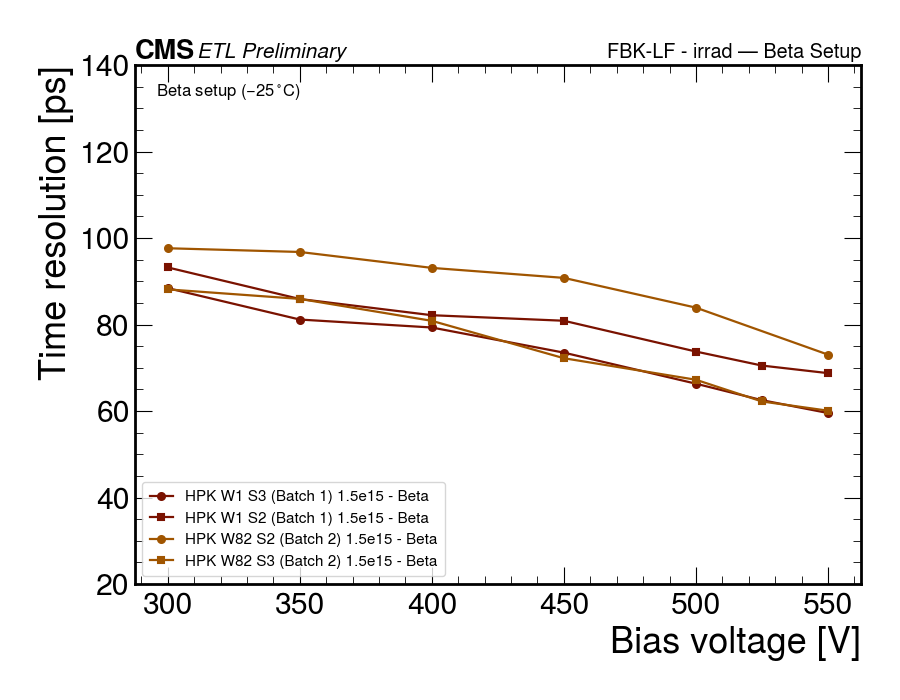

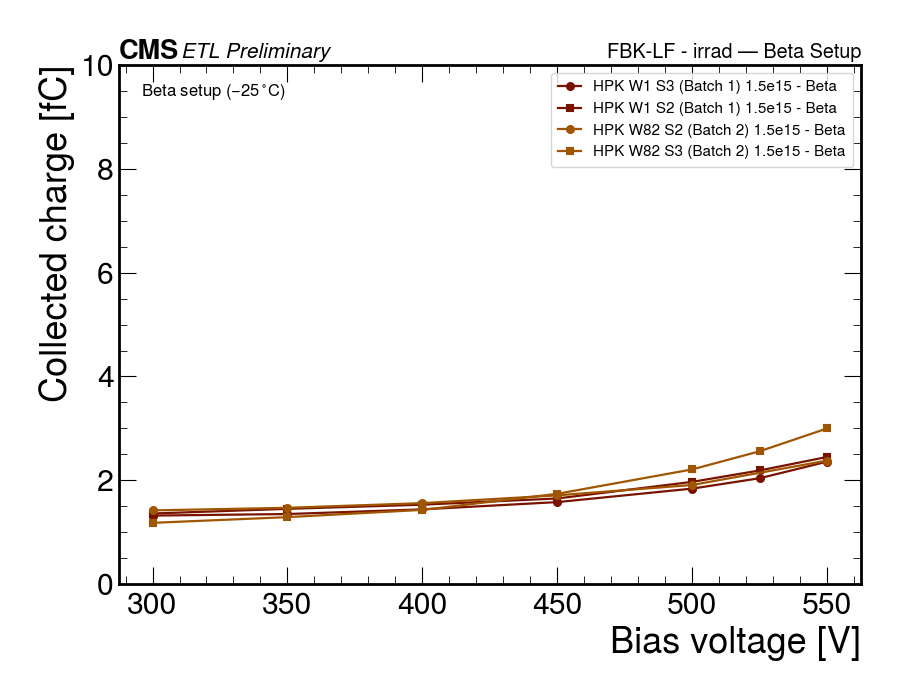

In [144]:

# ── Cosa plottare ────────────────────────────────────────────
#selection = [0,1,2,3,4,5,6,7] #HPK batch1 
#selection = [8,9,10,11,12,13,14,15] #HPK batch2
#selection = [0,1,2,3,8,9,10,11] #HPK
#selection = [26,27,28,29] #FBK
#selection = [16,17,18,19,20,21] #HPK6
#selection = [4,5,6,7,12,13,14,15,18,19,20,21,26,27,28,29] #all irradiated sensors
#selection = [4,5,12,13,18,19,26,27] #all 1e15
#selection = [6,7,14,15,20,21,28,29] #all 1.5e15
#selection = [0,2,8,10,16,17,30] #all hpk pre-rad
#selection = [4,5,12,13,18,19] #all hpk irrad 1e15
selection = [6,7,14,15] #all hpk irrad 15e15

PLOT_SUBTITLE = r"Beta setup ($-25^\circ$C)"
TITLE     = "FBK-LF - irrad — Beta Setup"
SUBTITLE  = PLOT_SUBTITLE          # oppure una stringa custom

# ── Limiti degli assi ────────────────────────────────────────
YLIM_RES    = (20, 140)   # ps
YLIM_CHARGE = (0, 10)    # fC

# ── Salvataggio (None = non salva) ───────────────────────────
# es. SAVE_PREFIX = "plots/hpk_batch"  →  hpk_batch_res.png, ecc.
SAVE_PREFIX = None

# ── Lancia i 3 plot ──────────────────────────────────────────
plot_three(selection, TITLE,
           subtitle    = SUBTITLE,
           ylim_res    = YLIM_RES,
           ylim_charge = YLIM_CHARGE,
           save_prefix = SAVE_PREFIX)


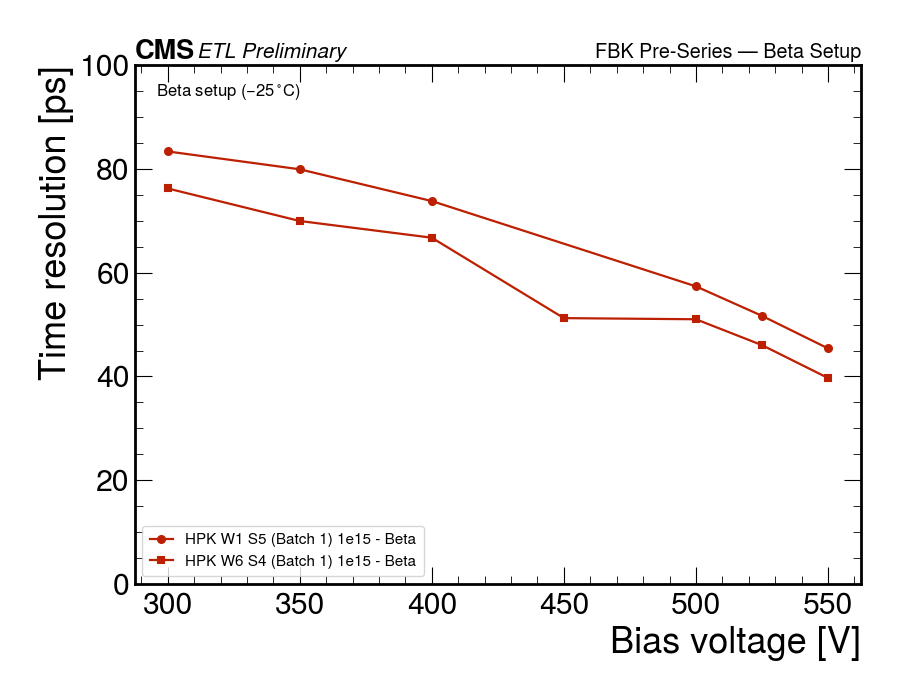

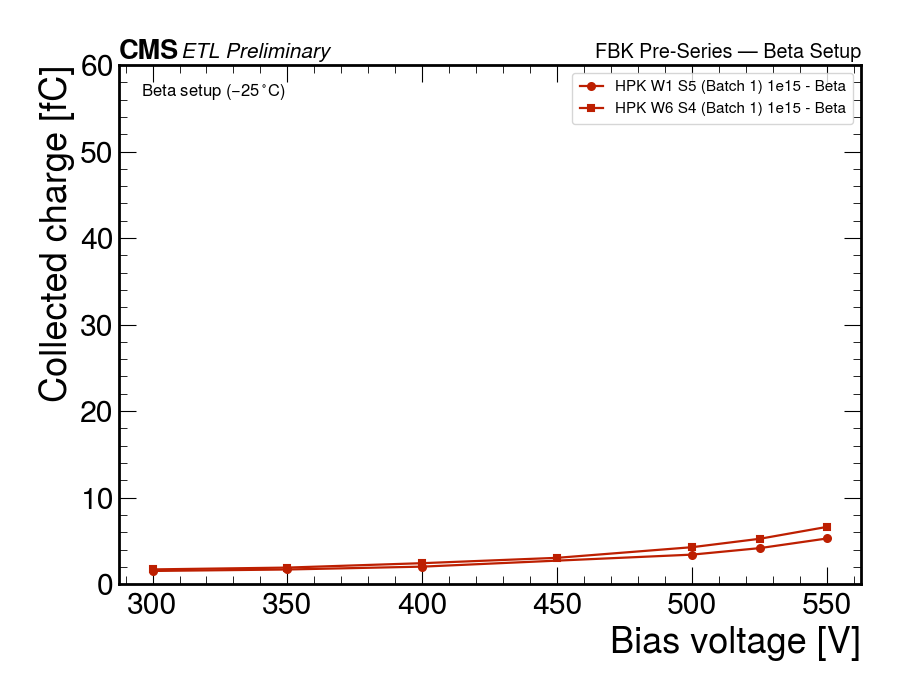

In [139]:
# ── Cosa plottare ────────────────────────────────────────────
selection = [4,5]          # indici, intero singolo, o 'all'
PLOT_SUBTITLE = r"Beta setup ($-25^\circ$C)"
TITLE     = "FBK Pre-Series — Beta Setup"
SUBTITLE  = PLOT_SUBTITLE          # oppure una stringa custom

# ── Limiti degli assi ────────────────────────────────────────
YLIM_RES    = (0, 100)   # ps
YLIM_CHARGE = (0, 60)    # fC

# ── Salvataggio (None = non salva) ───────────────────────────
# es. SAVE_PREFIX = "plots/hpk_batch"  →  hpk_batch_res.png, ecc.
SAVE_PREFIX = None

# ── Lancia i 3 plot ──────────────────────────────────────────
plot_three(selection, TITLE,
           subtitle    = SUBTITLE,
           ylim_res    = YLIM_RES,
           ylim_charge = YLIM_CHARGE,
           save_prefix = SAVE_PREFIX)

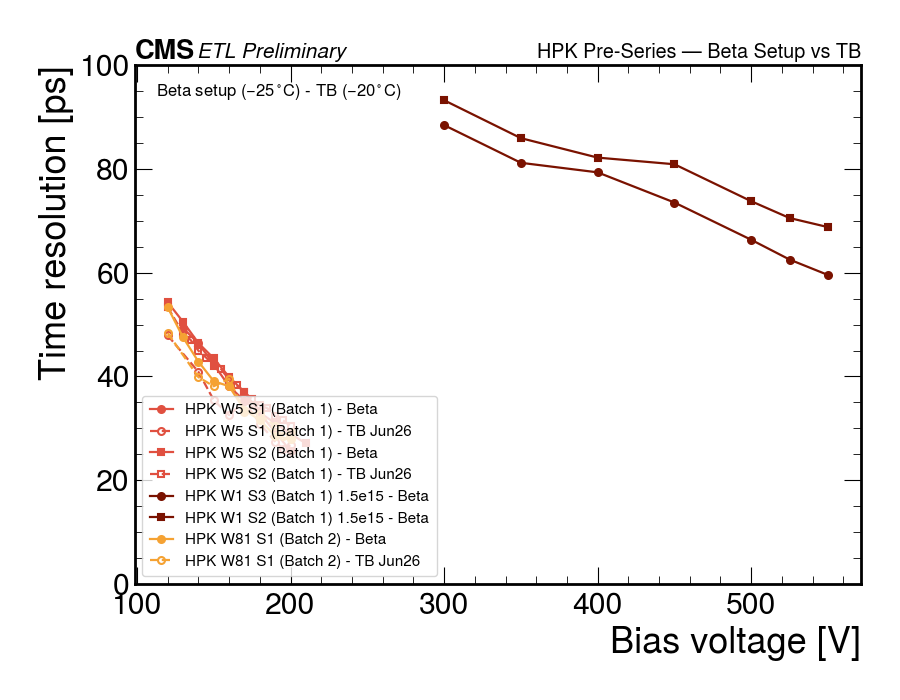

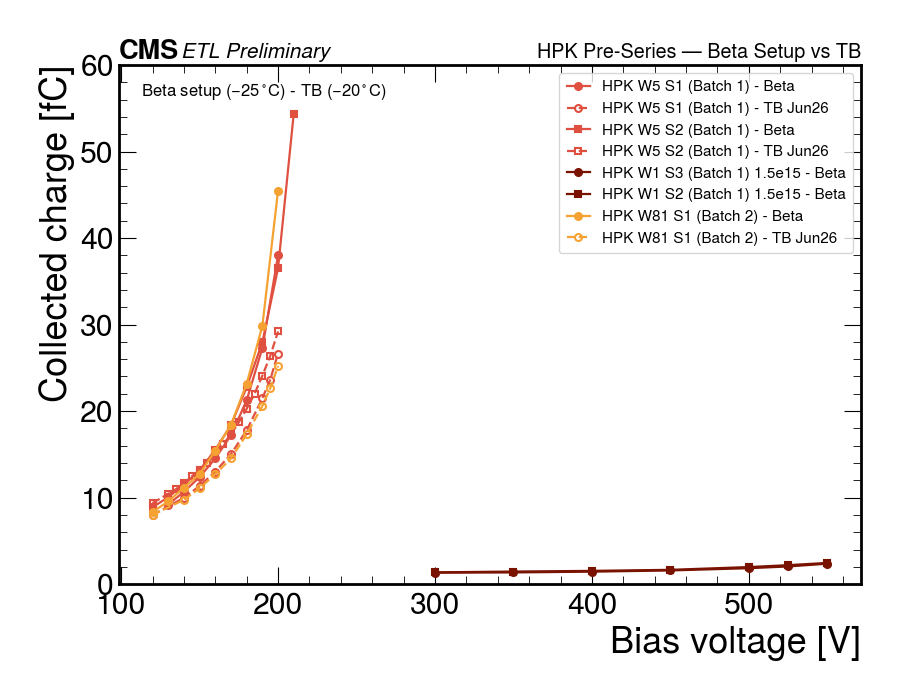

In [140]:
# ── Cosa plottare ────────────────────────────────────────────
selection = [0,1,2,3,6,7,8,9]          # indici, intero singolo, o 'all'
PLOT_SUBTITLE = r"Beta setup ($-25^\circ$C) - TB ($-20^\circ$C)"
TITLE     = "HPK Pre-Series — Beta Setup vs TB"
SUBTITLE  = PLOT_SUBTITLE          # oppure una stringa custom

# ── Limiti degli assi ────────────────────────────────────────
YLIM_RES    = (0, 100)   # ps
YLIM_CHARGE = (0, 60)    # fC

# ── Salvataggio (None = non salva) ───────────────────────────
# es. SAVE_PREFIX = "plots/hpk_batch"  →  hpk_batch_res.png, ecc.
SAVE_PREFIX = None

# ── Lancia i 3 plot ──────────────────────────────────────────
plot_three(selection, TITLE,
           subtitle    = SUBTITLE,
           ylim_res    = YLIM_RES,
           ylim_charge = YLIM_CHARGE,
           save_prefix = SAVE_PREFIX)

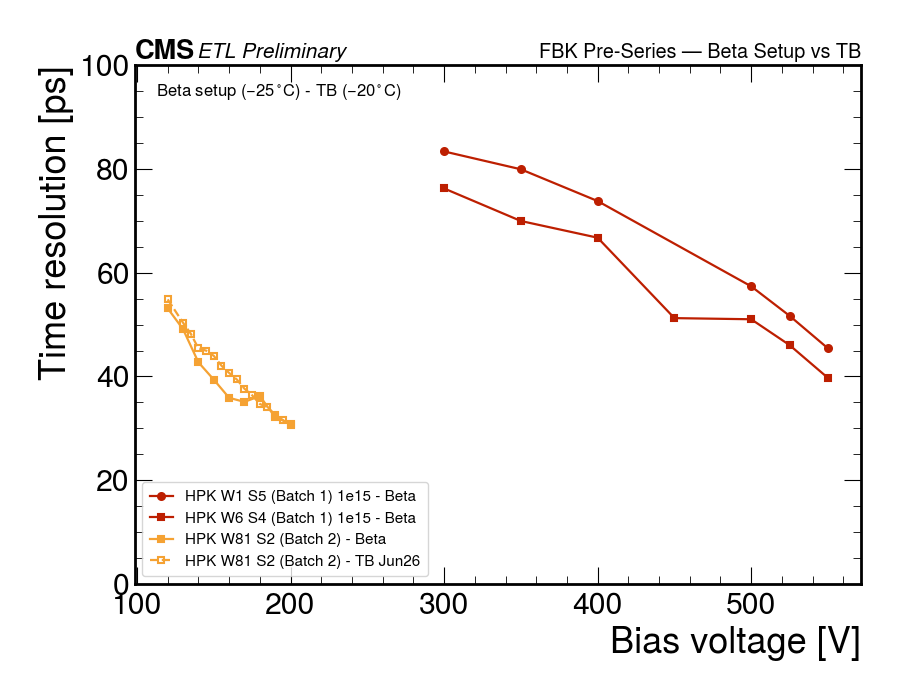

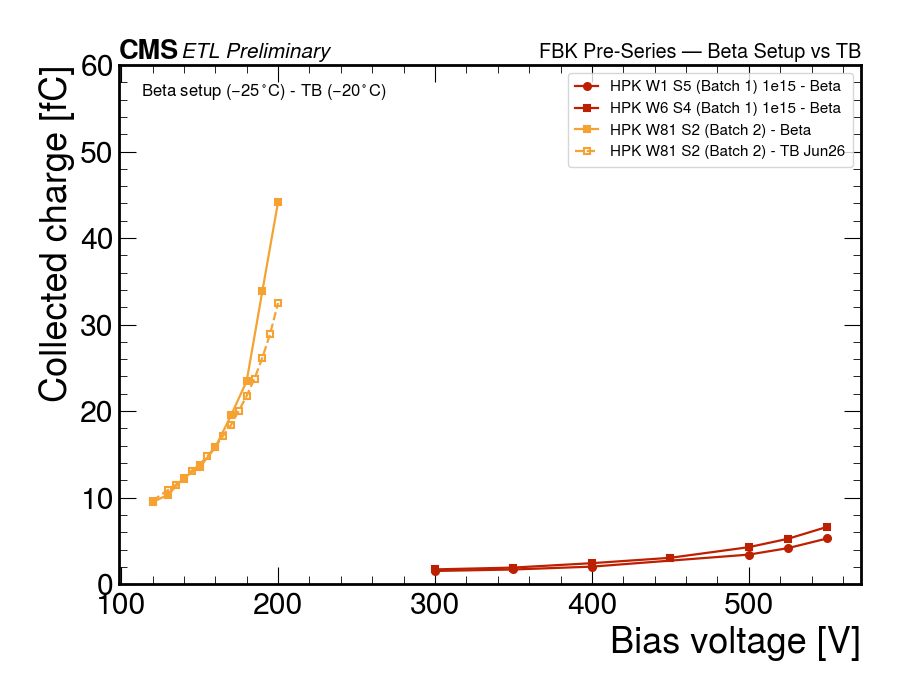

In [141]:
# ── Cosa plottare ────────────────────────────────────────────
selection = [4,5,10,11]          # indici, intero singolo, o 'all'
PLOT_SUBTITLE = r"Beta setup ($-25^\circ$C) - TB ($-20^\circ$C)"
TITLE     = "FBK Pre-Series — Beta Setup vs TB"
SUBTITLE  = PLOT_SUBTITLE          # oppure una stringa custom

# ── Limiti degli assi ────────────────────────────────────────
YLIM_RES    = (0, 100)   # ps
YLIM_CHARGE = (0, 60)    # fC

# ── Salvataggio (None = non salva) ───────────────────────────
# es. SAVE_PREFIX = "plots/hpk_batch"  →  hpk_batch_res.png, ecc.
SAVE_PREFIX = None

# ── Lancia i 3 plot ──────────────────────────────────────────
plot_three(selection, TITLE,
           subtitle    = SUBTITLE,
           ylim_res    = YLIM_RES,
           ylim_charge = YLIM_CHARGE,
           save_prefix = SAVE_PREFIX)

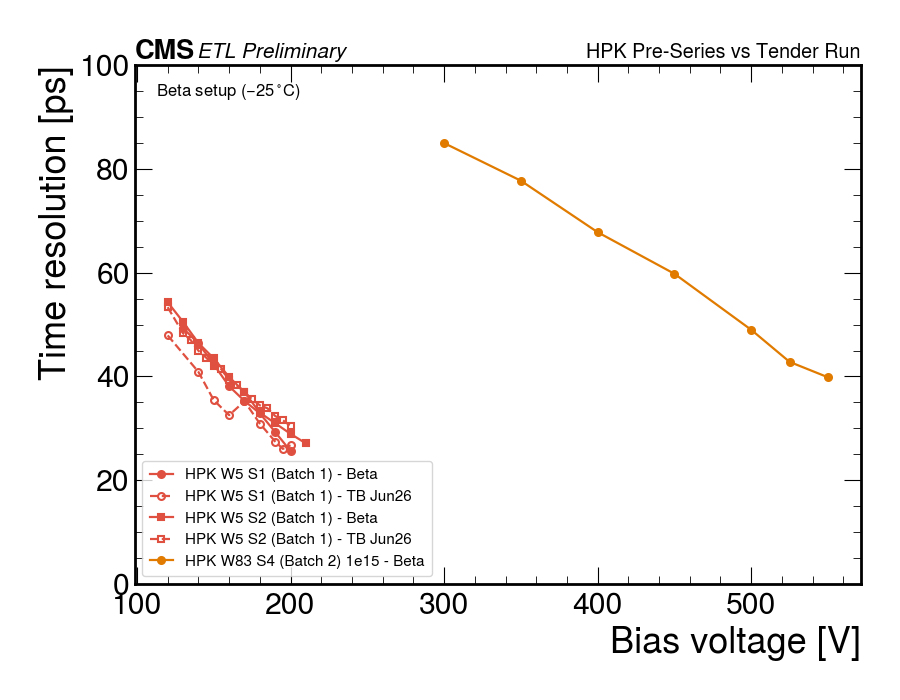

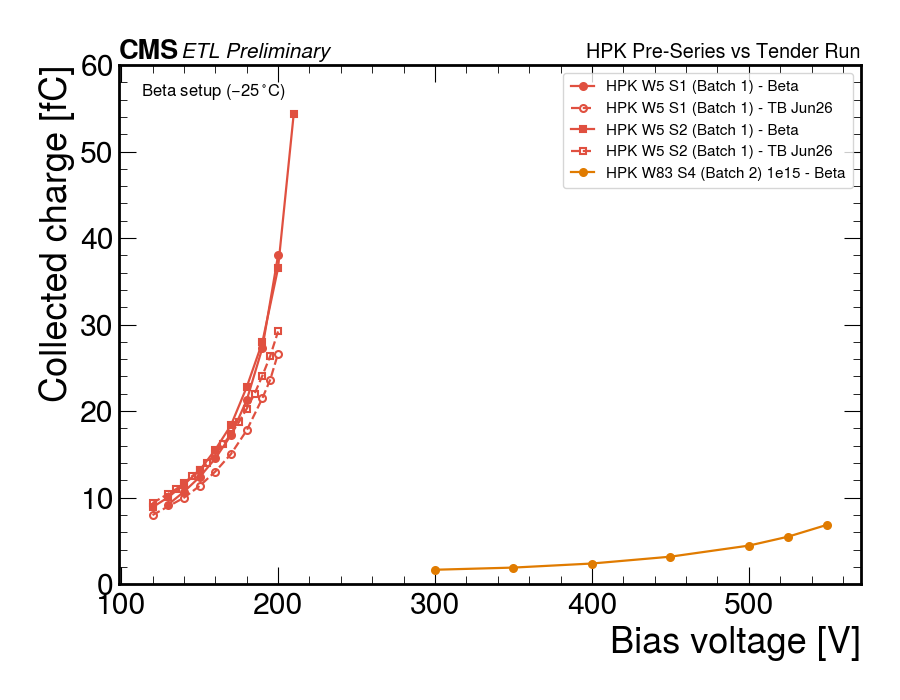

In [142]:
# ── Cosa plottare ────────────────────────────────────────────
selection = [0,1,2,3,12]          # indici, intero singolo, o 'all'
PLOT_SUBTITLE = r"Beta setup ($-25^\circ$C)"
TITLE     = "HPK Pre-Series vs Tender Run"
SUBTITLE  = PLOT_SUBTITLE          # oppure una stringa custom

# ── Limiti degli assi ────────────────────────────────────────
YLIM_RES    = (0, 100)   # ps
YLIM_CHARGE = (0, 60)    # fC

# ── Salvataggio (None = non salva) ───────────────────────────
# es. SAVE_PREFIX = "plots/hpk_batch"  →  hpk_batch_res.png, ecc.
SAVE_PREFIX = None

# ── Lancia i 3 plot ──────────────────────────────────────────
plot_three(selection, TITLE,
           subtitle    = SUBTITLE,
           ylim_res    = YLIM_RES,
           ylim_charge = YLIM_CHARGE,
           save_prefix = SAVE_PREFIX)

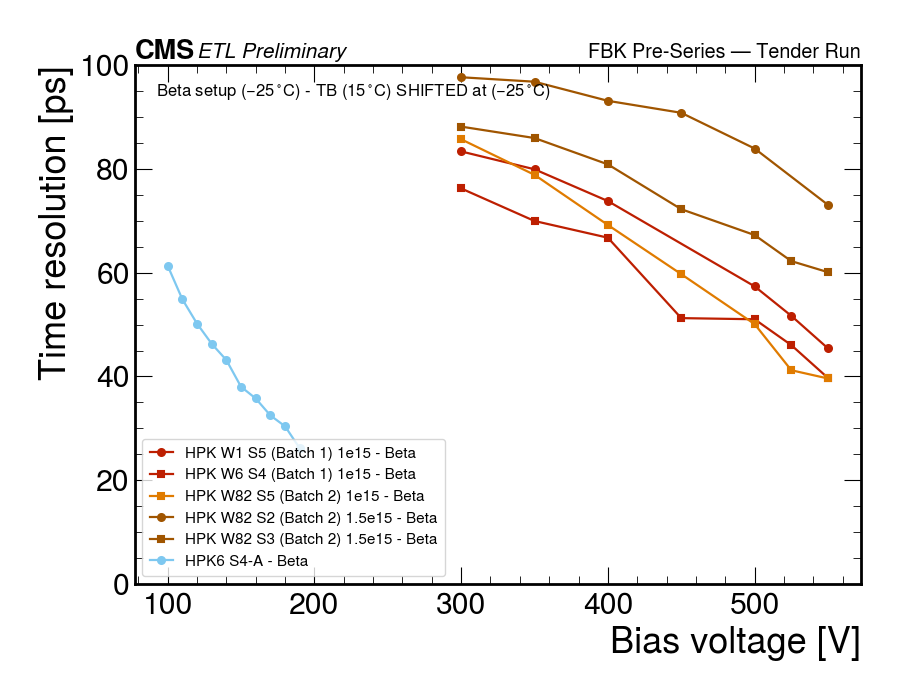

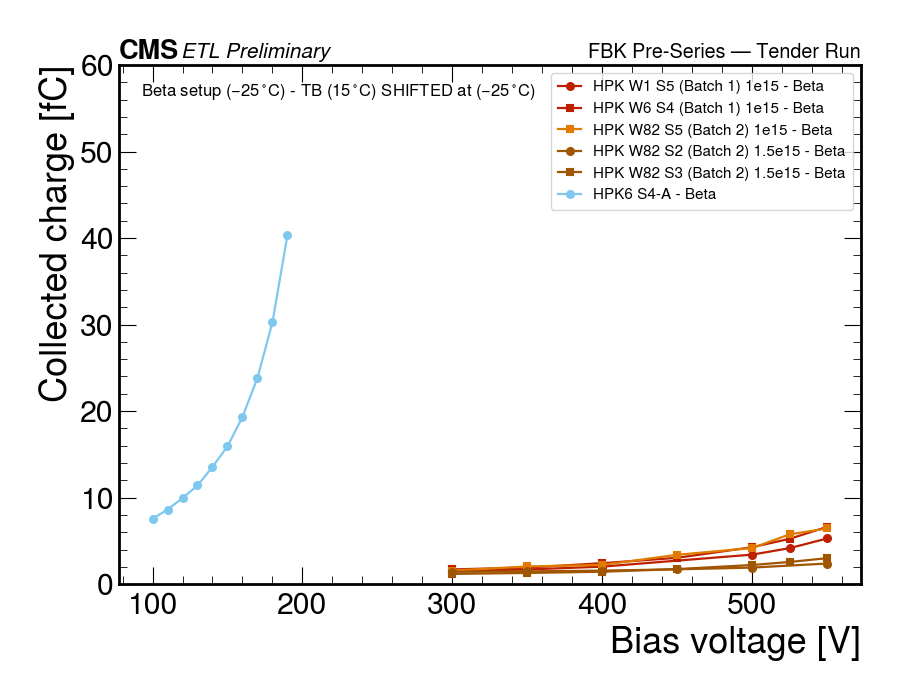

In [143]:
# ── Cosa plottare ────────────────────────────────────────────
selection = [4,5,13,14,15,16]          # indici, intero singolo, o 'all'
PLOT_SUBTITLE = r"Beta setup ($-25^\circ$C) - TB ($15^\circ$C) SHIFTED at ($-25^\circ$C) "
TITLE     = "FBK Pre-Series — Tender Run"
SUBTITLE  = PLOT_SUBTITLE          # oppure una stringa custom

# ── Limiti degli assi ────────────────────────────────────────
YLIM_RES    = (0, 100)   # ps
YLIM_CHARGE = (0, 60)    # fC

# ── Salvataggio (None = non salva) ───────────────────────────
# es. SAVE_PREFIX = "plots/hpk_batch"  →  hpk_batch_res.png, ecc.
SAVE_PREFIX = None

# ── Lancia i 3 plot ──────────────────────────────────────────
plot_three(selection, TITLE,
           subtitle    = SUBTITLE,
           ylim_res    = YLIM_RES,
           ylim_charge = YLIM_CHARGE,
           save_prefix = SAVE_PREFIX)